## Process
To combine the metrics, we used Min-Max Normalization. Because our datasets used different units, such as index values for air quality, counts for parks, and incident reports for safety, they could not be compared directly in their raw form. Each metric was rescaled to a consistent 0 to 1 scale. We then adjusted for "directionality": for parks, a higher count is better, but for air quality and safety, a lower number is better. By inverting the safety and air quality scores (subtracting the normalized value from 1), we ensured that the best performing neighborhood in every category received the highest score. Finally, we calculated an equally weighted average of these three scores to determine the overall ranking.

## Conclusion
When balancing air quality, park accessibility, and public safety with equal importance, Squirrel Hill South emerges as the best neighborhood in Pittsburgh. While Ridgemont is the safest and Lawrenceville offers the cleanest air, Squirrel Hill South’s large lead in parks with 8 city-managed parks, gives it a higher score.

C:\Users\paleg\AppData\Local\Temp\ipykernel_14488\2397966797.py:20: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  incidents_df = pd.read_csv(r"C:\Users\paleg\Downloads\incidents.csv")


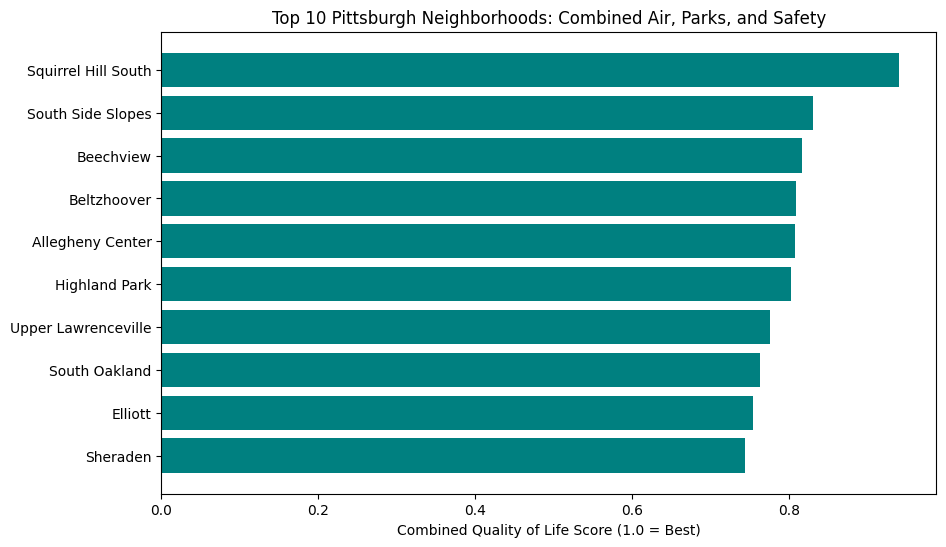

Top Overall Rankings:
           Neighborhood  Total_Score
92  Squirrel Hill South     0.941022
87    South Side Slopes     0.831029
8             Beechview     0.816811
9           Beltzhoover     0.809110
0      Allegheny Center     0.807530


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. LOAD DATA 
# Air Quality: Average AQI per Neighborhood
air_df = pd.read_csv(r"C:\Users\paleg\Downloads\airquality.csv")
air_df = air_df[['site', 'index_value']].dropna()
air_df['index_value'] = pd.to_numeric(air_df['index_value'], errors='coerce')
# Map measurement sites to Neighborhood names
air_scores = air_df.groupby('site')['index_value'].mean().reset_index()
air_scores['Neighborhood'] = air_scores['site'].str.replace(r'\s\d+$', '', regex=True)
air_scores = air_scores.groupby('Neighborhood')['index_value'].mean().reset_index()

# Parks: Total park count per Neighborhood
parks_df = pd.read_csv(r"C:\Users\paleg\Downloads\parks.csv")
park_counts = parks_df['neighborhood'].value_counts().reset_index()
park_counts.columns = ['Neighborhood', 'Park_Count']

# Safety: Total violent incidents (lower is better)
incidents_df = pd.read_csv(r"C:\Users\paleg\Downloads\incidents.csv")
# Filtering for 'Person' crimes
violent = incidents_df[incidents_df['NIBRS_Crime_Against'] == 'Person'].copy()
safety_scores = violent.groupby('Neighborhood').size().reset_index(name='Violent_Incidents')

# 2. MERGE DATASETS
# Combine all three metrics into one dataframe
final_df = park_counts.merge(safety_scores, on='Neighborhood', how='outer')
final_df = final_df.merge(air_scores, on='Neighborhood', how='outer')

# Fill missing values with 0 so the math doesn't break
final_df = final_df.fillna(0)

# 3. NORMALIZE AND COMBINE
# Parks: More is better
final_df['Park_Score'] = (final_df['Park_Count'] - final_df['Park_Count'].min()) / (final_df['Park_Count'].max() - final_df['Park_Count'].min())

# Safety: Fewer incidents is better (Invert the scale)
final_df['Safety_Score'] = 1 - ((final_df['Violent_Incidents'] - final_df['Violent_Incidents'].min()) / 
                                (final_df['Violent_Incidents'].max() - final_df['Violent_Incidents'].min()))

# Air Quality: Lower AQI index is better (Invert the scale)
final_df['Air_Score'] = 1 - ((final_df['index_value'] - final_df['index_value'].min()) / 
                             (final_df['index_value'].max() - final_df['index_value'].min()))

# Final Aggregate Score (Average of all three normalized metrics)
final_df['Total_Score'] = (final_df['Park_Score'] + final_df['Safety_Score'] + final_df['Air_Score']) / 3
final_df = final_df.sort_values(by='Total_Score', ascending=False)

# 4. VISUALIZATION
plt.figure(figsize=(10, 6))
top_10 = final_df.head(10)
plt.barh(top_10['Neighborhood'], top_10['Total_Score'], color='teal')
plt.xlabel('Combined Quality of Life Score (1.0 = Best)')
plt.title('Top 10 Pittsburgh Neighborhoods: Combined Air, Parks, and Safety')
plt.gca().invert_yaxis() 
plt.show()

print("Top Overall Rankings:")
print(final_df[['Neighborhood', 'Total_Score']].head(5))